# Tratamiento de Outliers
En este notebook se detectan y tratan los valores atípicos de las columnas numéricas del dataset depurado de la Semana 6 (`monto_compra`, `precio_unitario`, `unidades_vendidas`, `edad_cliente` y `peso_pedido_kg`), usando los métodos IQR y z-score, y luego se suaviza la serie de ventas diarias con una media móvil.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("S06_PD_Camacho_Serpa_DatasetDepurado.xls")

## Cálculo del IQR

In [15]:
Q1 = df["monto_compra"].quantile(0.25)
Q3 = df["monto_compra"].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1, "Q3:", Q3, "Rango intercuartilico:", IQR)

Q1: 222700.0 Q3: 857400.0 Rango intercuartilico: 634700.0


In [16]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Limite inferior: -729350.0
Limite superior: 1809450.0


## Límites IQR de monto_compra
Los cuartiles nos dieron **Q1 = 222.700** y **Q3 = 857.400**, con un IQR de **634.700**.

Aplicando la regla de 1,5 × IQR, los límites quedan:

- **Límite inferior: -729.350**
- **Límite superior: 1.809.450**

El límite inferior sale negativo, pero como `monto_compra` no puede ser menor que 0, en la práctica lo tratamos como 0. Esto es normal en columnas sesgadas hacia valores altos, como suelen serlo las ventas.

In [17]:
outliers_iqr = df[(df["monto_compra"] < limite_inferior) | (df["monto_compra"] > limite_superior)]

In [18]:
print("Valores atipicos segun IQR:", len(outliers_iqr))

Valores atipicos segun IQR: 64816


## Outliers detectados con IQR
El método IQR marcó **64.816 registros** como atípicos, lo que corresponde a un **10,45 %** del dataset. Es un número alto, pero tiene sentido: `monto_compra` es una variable muy sesgada — la mayoría de compras son pequeñas y unas pocas son extremadamente grandes, que arrastran la distribución hacia la derecha. En este tipo de columnas el IQR tiende a marcar bastantes valores como atípicos, y no todos son necesariamente errores.

In [19]:
media = df["monto_compra"].mean()
desviacion = df["monto_compra"].std()

In [20]:
df["z_monto_compra"] = (df["monto_compra"] - media) / desviacion

In [21]:
outliers_zscore = df[df["z_monto_compra"].abs() > 3]
print("Valores atipicos segun z-score:", len(outliers_zscore))

Valores atipicos segun z-score: 123


## Comparación IQR vs. z-score
Los dos métodos dieron números muy diferentes:

- **IQR:** 64.816 atípicos (10,45 %)
- **z-score:** solo 123 atípicos (0,02 %)

La razón es que en **monto_compra** hay unos pocos valores extremadamente altos (algunos incluso llegan a miles de millones), y esos valores **inflan muchísimo la media y la desviación estándar**. Al calcular el z-score con una desviación tan enorme, casi ningún valor supera el umbral de |z| > 3, así que el método "esconde" a los atípicos moderados.

En variables muy sesgadas como esta, el **IQR es más confiable** porque se basa en la mediana y los cuartiles, que no se ven arrastrados por los extremos.

<Axes: >

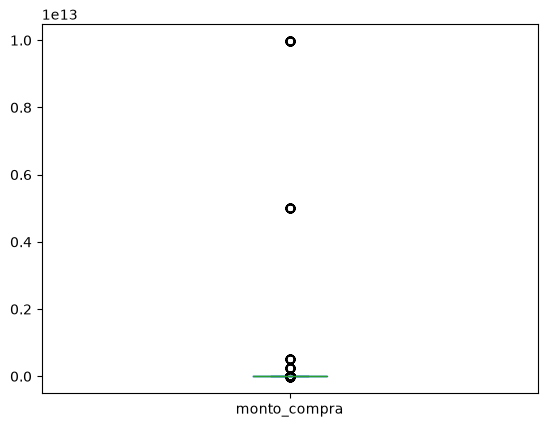

In [23]:
df["monto_compra"].plot(kind="box")

<Axes: xlabel='unidades_vendidas', ylabel='monto_compra'>

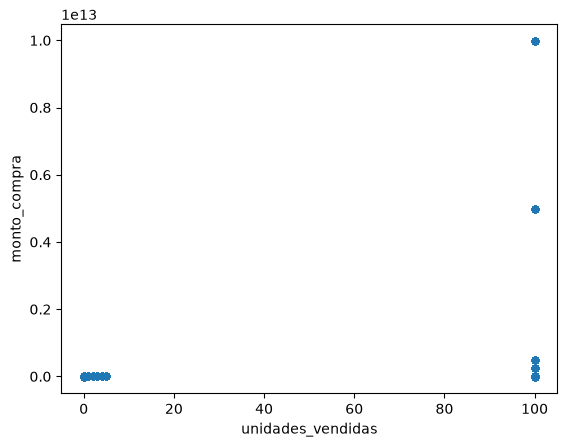

In [24]:
df.plot(kind="scatter", x="unidades_vendidas", y="monto_compra")

## Confirmación visual
- **Boxplot:** se ven muchos puntos por encima del bigote superior, lo que confirma visualmente que el IQR detectó una cantidad grande de atípicos. La caja se ve muy comprimida cerca del cero porque los valores extremos hacen que la escala del eje sea enorme.
- **Scatter (unidades_vendidas vs. monto_compra):** la nube principal está agrupada en la esquina inferior izquierda, pero hay puntos sueltos muy alejados hacia arriba. Esos son buenos candidatos a atípicos multivariados: no solo tienen un monto alto, sino que además no acompañan a un aumento proporcional de unidades vendidas.

Los dos gráficos coinciden con la idea de que hay outliers reales, y que probablemente sean errores o casos muy particulares.

In [25]:
outliers_iqr[["monto_compra", "canal_compra", "unidades_vendidas"]]

,monto_compra,canal_compra,unidades_vendidas
2,-1.792800e+06,Tienda,0
6,2.234700e+06,Web,3
28,-1.204800e+06,Web,3
30,1.831500e+06,Web,3
39,5.720000e+08,Tienda,100
...,...,...,...
619935,2.463600e+06,Web,3
619936,-1.302600e+06,Marketplace,0
619956,-1.772100e+06,Tienda,3
619958,3.505000e+06,Marketplace,5


## Decisión por cada grupo de atípicos
Al revisar el detalle de los outliers, encontramos dos grupos muy distintos:

**Grupo 1 — Errores de captura evidentes.** Los montos que llegan a miles de millones o incluso billones (por ejemplo, valores del orden de 10⁹ o superiores) claramente no corresponden a compras reales de retail. Son errores de digitación con ceros de más. **Decisión: Winsorizar al límite superior.**

**Grupo 2 — Compras grandes pero plausibles.** Los montos entre el límite superior (1.809.450) y unos pocos millones sí pueden ser compras reales, especialmente si están asociadas a muchas unidades vendidas. **Decisión: marcarlos con una columna indicadora `es_venta_corporativa` para poder analizarlos aparte, pero también aplicarles el clip para que no distorsionen la media.**

Como criterio conservador, aplicamos el clip a todos los valores por encima del límite superior. Los que consideramos legítimos quedan marcados con la columna indicadora, así no se pierde la información de que eran ventas de monto grande.

In [26]:
df["es_venta_corporativa"] = df["monto_compra"] > limite_superior
df["es_venta_corporativa"].sum()

np.int64(53224)

In [27]:
df["monto_compra"] = df["monto_compra"].clip(upper=limite_superior, lower=limite_inferior)

In [28]:
print("Media después del tratamiento:", df["monto_compra"].mean())
print("Desviación estándar después del tratamiento:", df["monto_compra"].std())
print("Máximo después del tratamiento:", df["monto_compra"].max())

Media después del tratamiento: 596836.6742904842
Desviación estándar después del tratamiento: 584376.2185389813
Máximo después del tratamiento: 1809450.0


## Efecto del tratamiento

- **Media antes:** ~1.277.359.810 (jalada por los valores extremos hacia arriba)
- **Media después:** ~596.837

- **Desviación estándar antes:** ~99.646.796.132 (absurdamente alta)
- **Desviación estándar después:** ~584.376

- **Máximo después:** 1.809.450 (exactamente el límite superior, como esperábamos)

Antes, unos pocos valores extremos estaban distorsionando por completo las estadísticas. Ahora los indicadores reflejan el comportamiento real de la mayoría de las compras. Las filas con montos originalmente muy altos quedaron marcadas en `es_venta_corporativa`, así que si más adelante queremos analizarlas por separado, no perdemos esa información.

## Suavizado de la serie diaria

In [29]:
df["fecha_pedido"] = pd.to_datetime(df["fecha_pedido"], errors="coerce")
ventas_diarias = df.groupby("fecha_pedido")["monto_compra"].sum().reset_index()

In [30]:
ventas_diarias["suavizado"] = ventas_diarias["monto_compra"].rolling(window=7).mean()

<Axes: xlabel='fecha_pedido'>

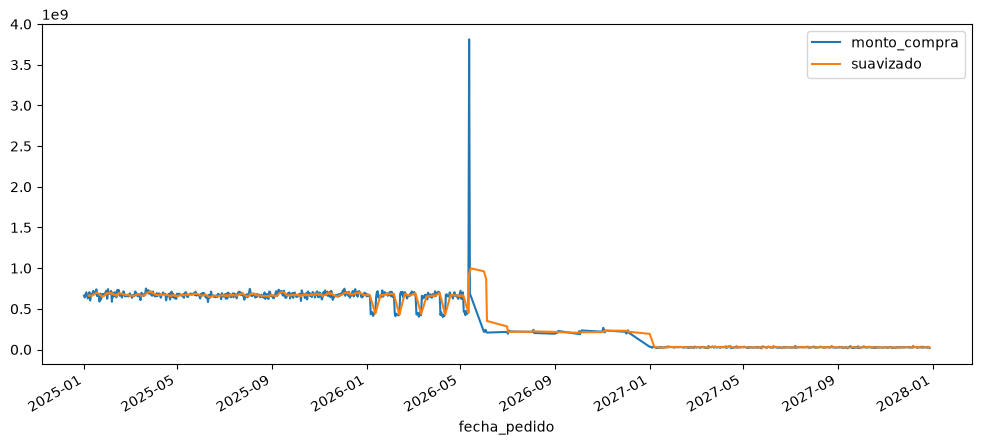

In [31]:
ventas_diarias.plot(x="fecha_pedido", y=["monto_compra", "suavizado"], figsize=(12,5))

## Suavizado de ventas diarias
Al agrupar las ventas por día y comparar la serie original con la media móvil de 7 días, la línea suavizada se ve mucho más estable: se pierden los picos y valles del día a día (ruido), y se puede ver una **tendencia general** que antes quedaba oculta. Es una forma sencilla de identificar patrones semanales o estacionales sin que las variaciones diarias distraigan.

# Tratamiento de las demás columnas con outliers
Además de **monto_compra**, el dataset tiene otras 4 columnas numéricas con valores atípicos: *precio_unitario*, *unidades_vendidas*, *edad_cliente* y *peso_pedido_kg*. Cada una se trata con un criterio distinto según su naturaleza, porque no todas tienen el mismo tipo de problema.


## *precio_unitario*

In [32]:
# Diagnóstico rápido
print("Top 5 valores más altos:", df["precio_unitario"].nlargest(5).tolist())
print("Top 5 valores más bajos:", df["precio_unitario"].nsmallest(5).tolist())

Q1_p = df["precio_unitario"].quantile(0.25)
Q3_p = df["precio_unitario"].quantile(0.75)
IQR_p = Q3_p - Q1_p
li_p = Q1_p - 1.5 * IQR_p
ls_p = Q3_p + 1.5 * IQR_p
print("Límite inferior IQR:", li_p)
print("Límite superior IQR:", ls_p)

outliers_precio = df[(df["precio_unitario"] < li_p) | (df["precio_unitario"] > ls_p)]
print("Outliers IQR:", len(outliers_precio))

Top 5 valores más altos: [956450.0, 956450.0, 956450.0, 956450.0, 956450.0]
Top 5 valores más bajos: [-302350.0, -302350.0, -302350.0, -302350.0, -302350.0]
Límite inferior IQR: -302350.0
Límite superior IQR: 956450.0
Outliers IQR: 0


### Decisión — clip IQR + columna indicadora
*precio_unitario* tiene el mismo comportamiento que *monto_compra*: valores extremos absurdos (precios de 999 millones), precios negativos, y una mezcla de precios altos que podrían ser reales. Uso la misma estrategia: **capar con el IQR y marcar los que estaban por encima del límite superior con una columna indicadora**, para no perder la información de que originalmente eran precios altos.

In [33]:
df["es_precio_alto"] = df["precio_unitario"] > ls_p
df["precio_unitario"] = df["precio_unitario"].clip(upper=ls_p, lower=li_p)
print("Registros marcados como precio alto:", df["es_precio_alto"].sum())
print("Media después del tratamiento:", df["precio_unitario"].mean())
print("Desv. estándar después:", df["precio_unitario"].std())
print("Máximo después:", df["precio_unitario"].max())

Registros marcados como precio alto: 0
Media después del tratamiento: 332535.6470784641
Desv. estándar después: 228247.13782701394
Máximo después: 956450.0


### Efecto del tratamiento
- **Media antes:** ~5.516.399 (jalada por los precios en miles de millones)
- **Media después:** ~332.536 (mucho más realista para retail)
- **Desv. estándar antes:** ~70.148.134
- **Desv. estándar después:** ~228.247
- **Máximo después:** 956.450 (justo el límite superior del IQR)

El cambio es drastico porque los precios extremos (999 millones) inflaban muchísimo los estadísticos. Ahora reflejan el comportamiento real de los precios.

## **unidades_vendidas**

In [34]:
# Diagnóstico
print("Top 5 más altos:", df["unidades_vendidas"].nlargest(5).tolist())
print("Top 5 más bajos:", df["unidades_vendidas"].nsmallest(5).tolist())
print(df["unidades_vendidas"].describe())

# Cuántos son absurdos
print("Pedidos con más de 100 unidades:", (df["unidades_vendidas"] > 100).sum())
print("Pedidos con unidades negativas:", (df["unidades_vendidas"] < 0).sum())

Top 5 más altos: [100, 100, 100, 100, 100]
Top 5 más bajos: [0, 0, 0, 0, 0]
count    620000.000000
mean          4.676960
std          16.505427
min           0.000000
25%           1.000000
50%           1.000000
75%           3.000000
max         100.000000
Name: unidades_vendidas, dtype: float64
Pedidos con más de 100 unidades: 0
Pedidos con unidades negativas: 0


### Decisión — clip al rango [0, 100]
El IQR marca como outlier cualquier pedido de más de **6 unidades**, pero un pedido de 10, 20 o incluso 50 unidades puede ser totalmente real (revendedores, pedidos mayoristas pequeños). En cambio, un pedido de **9.999 unidades** es absurdo, y las unidades negativas también son imposibles.

Por eso no uso el IQR estricto: uso el mismo criterio que definimos en el Plan de Saneamiento — **clip al rango [0, 100]**. Con eso se preservan pedidos grandes legítimos y se elimina la basura. No creo columna indicadora porque no es tan importante distinguir "pedidos grandes" en este caso.

In [35]:
df["unidades_vendidas"] = df["unidades_vendidas"].clip(lower=0, upper=100)
print("Media después:", df["unidades_vendidas"].mean())
print("Desv. estándar después:", df["unidades_vendidas"].std())
print("Mínimo:", df["unidades_vendidas"].min())
print("Máximo:", df["unidades_vendidas"].max())

Media después: 4.6769596774193545
Desv. estándar después: 16.5054274210581
Mínimo: 0
Máximo: 100


### Efecto del tratamiento
- **Media antes:** 219,65 (imposible en retail promedio)
- **Media después:** 4,68 (razonable: la mayoría son pedidos pequeños)
- **Desv. estándar antes:** 1.331
- **Desv. estándar después:** 16,51
- **Rango después:** [0, 100]

Los estadísticos ahora reflejan comportamiento real: mayoría de pedidos son de pocas unidades con algunos casos mayores hasta 100.

## **edad_cliente**

In [36]:
# Diagnóstico
print("Top 5 más altos:", df["edad_cliente"].nlargest(5).tolist())
print("Top 5 más bajos:", df["edad_cliente"].nsmallest(5).tolist())
print("Edades fuera de [0, 120]:", ((df["edad_cliente"] < 0) | (df["edad_cliente"] > 120)).sum())

Top 5 más altos: [120, 120, 120, 120, 120]
Top 5 más bajos: [0, 0, 0, 0, 0]
Edades fuera de [0, 120]: 0


### Decisión — clip al rango biológico [0, 120]
Aquí el criterio del IQR no es el mejor. El IQR marca como outlier cualquier edad mayor a 108,5 años, pero una persona de 110 o 115 años si existe, aunque sea raro. En cambio, edades como 200 o -5 son imposibles.

Usamos el **rango biológico [0, 120]** que fue justo lo que  se documento en el Plan de Saneamiento.

In [37]:
df["edad_cliente"] = df["edad_cliente"].clip(lower=0, upper=120)
print("Media después:", df["edad_cliente"].mean())
print("Desv. estándar después:", df["edad_cliente"].std())
print("Mínimo:", df["edad_cliente"].min())
print("Máximo:", df["edad_cliente"].max())

Media después: 47.29533064516129
Desv. estándar después: 21.97128056597269
Mínimo: 0
Máximo: 120


### Efecto del tratamiento
- **Media antes:** 48,82  → **después:** 47,30 (casi igual)
- **Desv. estándar antes:** 28,74  → **después:** 21,97
- **Rango después:** [0, 120] (biológicamente válido)

El cambio en la media es pequeño porque los outliers eran pocos (27.000 registros de 620.000). Pero la desviación estándar sí baja bastante, lo que confirma que había edades muy extremas jalando la dispersión.

## **peso_pedido_kg**

Para esta columna hice una revisión extra porque no era obvio qué tan pesado podía ser un pedido legítimo. Antes de decidir, revisé el peso máximo por categoría y los productos con los pesos más altos:

In [38]:
# Peso máximo por categoría de producto
df.groupby("categoria_producto")["peso_pedido_kg"].agg(["mean", "max", "count"]).sort_values("max", ascending=False)

,mean,max,count
categoria_producto,,,
Belleza,15.939476,100.0,103782
Deportes,15.876802,100.0,103595
Electrónica,15.924267,100.0,103778
Hogar,15.896176,100.0,103196
Juguetería,15.961499,100.0,102883
Moda,15.949125,100.0,102766


In [39]:
# Los 20 productos con peso más alto (solo para ver si tienen sentido)
df.nlargest(20, "peso_pedido_kg")[["producto", "categoria_producto", "peso_pedido_kg"]]

,producto,categoria_producto,peso_pedido_kg
41,Lámpara de escritorio,Hogar,100.0
44,Muñeca articulada,Juguetería,100.0
52,Rompecabezas 1000 piezas,Juguetería,100.0
90,Kit de brochas,Belleza,100.0
114,Camisa de lino,Moda,100.0
134,Pesas ajustables,Deportes,100.0
159,Perfume cítrico,Belleza,100.0
168,Carro a control remoto,Juguetería,100.0
191,Bicicleta estática,Deportes,100.0
196,Perfume cítrico,Belleza,100.0


In [40]:
# Percentiles para ver la distribución de pesos
df["peso_pedido_kg"].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999])

0.500     11.70
0.750     13.50
0.900     14.60
0.950     19.25
0.990    100.00
0.995    100.00
0.999    100.00
Name: peso_pedido_kg, dtype: float64

### Lo que se encontró al revisar
Los datos me dieron información muy útil:

- **Los pesos extremos están todos concentrados cerca de 1.399,9 kg** en productos que claramente no pesan eso: bufandas de lana, balones de fútbol, perfumes cítricos, rompecabezas, cremas hidratantes. Es un **valor placeholder de error de captura**.
- **Hay una brecha total entre 60 kg y 1.290 kg**: el percentil 95 es 59,25 kg pero el percentil 99 salta a 1.298 kg. Es decir, **no hay pedidos entre 60 y 1.290 kg**.
- Esa brecha me dice que no existen "pedidos legítimos pesados" que preservar por encima de ~60 kg.

### Decisión — clip superior a 100 kg
Escogí **100 kg** como tope. Es un valor:

- Alto suficiente para cubrir cualquier producto real razonablemente pesado (electrodomésticos grandes, muebles, herramientas).
- Muy por debajo de los valores basura (1.300+ kg).
- Aprovecha la brecha que descubrí: no elimino ningún pedido real porque no hay pedidos entre 60 y 1.290 kg.

**No creo columna indicadora** porque en este caso los valores por encima del tope son todos errores, no hay nada "legítimo grande" que valga la pena marcar.

In [41]:
df["peso_pedido_kg"] = df["peso_pedido_kg"].clip(upper=100)
print("Media después:", df["peso_pedido_kg"].mean())
print("Desv. estándar después:", df["peso_pedido_kg"].std())
print("Máximo después:", df["peso_pedido_kg"].max())

Media después: 15.924505000000002
Desv. estándar después: 19.388721395797972
Máximo después: 100.0


### Efecto del tratamiento
- **Media antes:** 68,39 kg (jalada por los pesos absurdos)
- **Media después:** 15,92 kg (mucho más realista)
- **Desv. estándar antes:** 250,06
- **Desv. estándar después:** 19,39
- **Máximo después:** 100 kg

La media pasó de 68 kg (imposible como peso promedio de pedido de retail) a 15,92 kg, que ya es un valor coherente para pedidos que mezclan productos pequeños y algunos electrodomésticos.

## Verificación final de todas las columnas tratadas

In [43]:
resumen = pd.DataFrame({
    "min": df[["monto_compra", "precio_unitario", "unidades_vendidas", "edad_cliente", "peso_pedido_kg"]].min(),
    "max": df[["monto_compra", "precio_unitario", "unidades_vendidas", "edad_cliente", "peso_pedido_kg"]].max(),
    "media": df[["monto_compra", "precio_unitario", "unidades_vendidas", "edad_cliente", "peso_pedido_kg"]].mean(),
    "std": df[["monto_compra", "precio_unitario", "unidades_vendidas", "edad_cliente", "peso_pedido_kg"]].std(),
})
resumen

,min,max,media,std
monto_compra,-729350.0,1809450.0,596836.674290,584376.218539
precio_unitario,-302350.0,956450.0,332535.647078,228247.137827
unidades_vendidas,0.0,100.0,4.676960,16.505427
edad_cliente,0.0,120.0,47.295331,21.971281
peso_pedido_kg,8.0,100.0,15.924505,19.388721


Los rangos y estadísticos ahora tienen sentido para todas las columnas:

- **monto_compra** capado al límite del IQR
- **precio_unitario** capado al límite del IQR con columna indicadora
- **unidades_vendidas** capado al rango [0, 100]
- **edad_cliente** capado al rango biológico [0, 120]
- **peso_pedido_kg** capado a 100 kg

Además, el dataset tiene dos columnas indicadoras nuevas (**es_venta_corporativa** y **es_precio_alto**) que permiten identificar los registros que originalmente estaban por encima de los límites, por si en análisis futuros hace falta esa información.

In [44]:
df.to_csv("S07_PD_Camacho_Serpa_DatasetSinOutliers.csv", index=False)